Simulando N = 100...
Simulando N = 500...
Simulando N = 1000...
Simulando N = 5000...


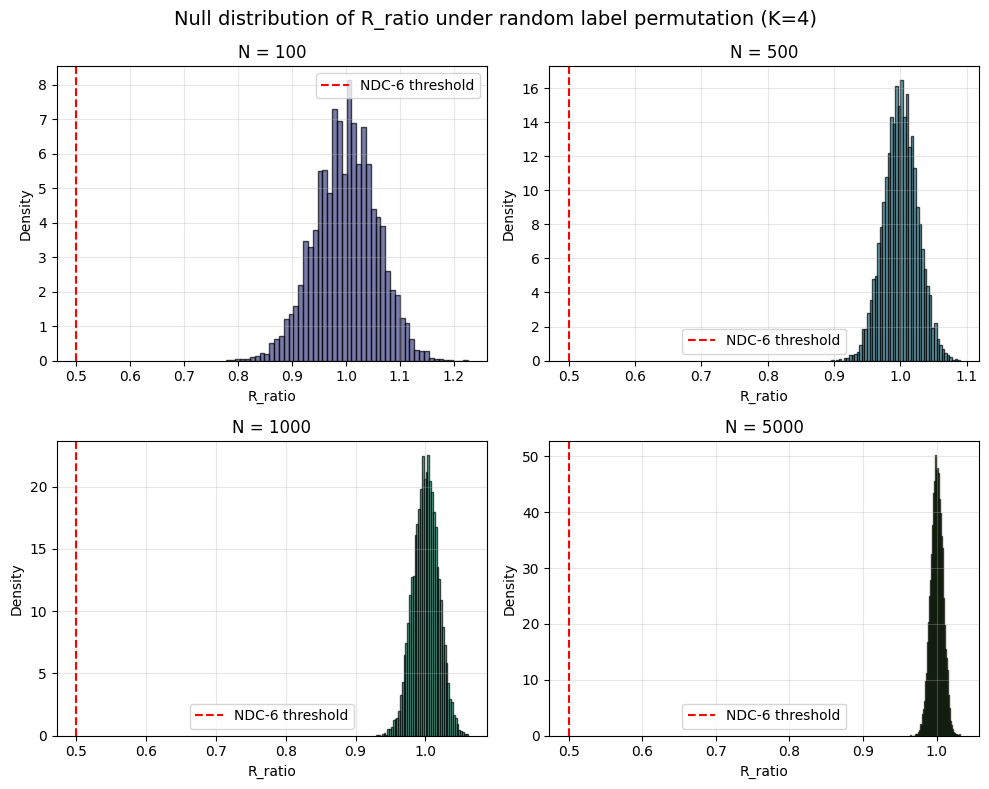

Figura salva: rratio_null_histogram.tiff (1200 dpi) e rratio_null_histogram.png (150 dpi)


In [1]:
#!/usr/bin/env python3
"""
rratio_null_histogram.py
========================
Gera a distribuição nula de R_ratio sob permutação uniforme
para diferentes comprimentos de sequência (N = 100, 500, 1000, 5000)
com K = 4 categorias equiprováveis.

A figura gerada (histogramas empilhados) reproduz a Figura 8 do manuscrito
e é salva em formato TIFF com 1200 dpi.
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

K = 4                     # número de categorias (clusters)
N_values = [100, 500, 1000, 5000]
n_simulations = 10000     # número de permutações para cada N

# Lista para armazenar os resultados
all_R_ratio = []

for N in N_values:
    print(f"Simulando N = {N}...")
    R_ratio_list = []
    # Probabilidades uniformes para cada categoria
    probs = np.ones(K) / K
    
    for _ in range(n_simulations):
        # Gerar contagens n_k de uma distribuição multinomial (permutação uniforme)
        n_k = np.random.multinomial(N, probs)
        # Gerar uma sequência de rótulos com essas contagens e permutar
        labels = np.repeat(np.arange(K), n_k)
        np.random.shuffle(labels)
        # Calcular número de runs
        runs = 1 + np.sum(labels[:-1] != labels[1:])
        # Valor esperado sob permutação (fórmula exata)
        R_null = 1 + (N * N - np.sum(n_k * n_k)) / N
        R_ratio = runs / R_null
        R_ratio_list.append(R_ratio)
    all_R_ratio.append(R_ratio_list)

# Criar a figura com subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False)
axes = axes.flatten()
colors = sns.color_palette("viridis", len(N_values))

for i, (N, R_vals) in enumerate(zip(N_values, all_R_ratio)):
    ax = axes[i]
    ax.hist(R_vals, bins=50, density=True, alpha=0.7, color=colors[i], edgecolor='black')
    ax.set_title(f'N = {N}')
    ax.set_xlabel('R_ratio')
    ax.set_ylabel('Density')
    ax.axvline(0.5, color='red', linestyle='--', label='NDC-6 threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Null distribution of R_ratio under random label permutation (K=4)', fontsize=14)
plt.tight_layout()

# Salvar em TIFF com 1200 dpi
plt.savefig('rratio_null_histogram.tiff', dpi=1200, format='tiff', pil_kwargs={'compression': 'tiff_lzw'})
# Salvar também uma versão PNG para pré‑visualização (opcional)
plt.savefig('rratio_null_histogram.png', dpi=150)

plt.show()

print("Figura salva: rratio_null_histogram.tiff (1200 dpi) e rratio_null_histogram.png (150 dpi)")